<a href="https://colab.research.google.com/github/youkjang/gefs_temperature_bias_correction/blob/main/notebooks/03_ml_bias_correction_with_source_files.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GEFS 2-m Temperature ML Bias Correction with Source Files

## 1. Project Overview

This notebook tests machine-learning-based bias correction for GEFS ensemble-mean 2-m temperature forecasts.

The goal is to see whether simple ML models can predict the forecast correction term:

`analysis - forecast`

The predicted correction is added to the raw GEFS forecast to create an ML-corrected forecast.

This notebook compares:

1. Raw GEFS
2. Mean-bias correction
3. Linear regression correction
4. Ridge regression correction
5. Histogram Gradient Boosting correction

The models are trained using a matched GEFS forecast and GFS analysis NetCDF dataset. Results are evaluated with bias, RMSE, and MAE to determine whether ML correction improves the forecast compared with raw GEFS and the mean-bias baseline.

## 2. Install/import packages

In Google Colab, run the install cell after cloning or uploading the repository. The `pandas==2.2.2` pin avoids the Colab pandas 3.x dependency conflict.

In [9]:
!pip -q install "eccodes>=2.37.0" cfgrib s3fs "fsspec==2025.3.0"

In [10]:
#!pip uninstall -y gefs_temperature_bias_correction

In [11]:
!pip install git+https://github.com/youkjang/gefs_temperature_bias_correction.git

  Cloning https://github.com/youkjang/gefs_temperature_bias_correction.git to /tmp/pip-req-build-nv79gwdn
  Running command git clone --filter=blob:none --quiet https://github.com/youkjang/gefs_temperature_bias_correction.git /tmp/pip-req-build-nv79gwdn
  Resolved https://github.com/youkjang/gefs_temperature_bias_correction.git to commit 89749e48673d70be4588eadec505cb430d5cfc5b
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [12]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from gefs_bias_correction.data import load_matched_dataset, print_dataset_summary
from gefs_bias_correction.split import split_train_test_by_init_date
from gefs_bias_correction.mean_bias import compute_mean_bias_by_lead, apply_mean_bias_correction
from gefs_bias_correction.ml_features import make_feature_arrays, sample_training_data
from gefs_bias_correction.ml_models import train_models, predict_corrected_forecast

In [13]:
from gefs_bias_correction.verification import compute_metrics_by_fhr, combine_results_with_improvement


In [14]:
from gefs_bias_correction.plotting import plot_rmse_by_fhr, plot_rmse_improvement, plot_spatial_error_example

## 3. User settings

Set `DATASET_PATH` to the saved NetCDF file created from the matched GEFS–GFS data-preparation notebook.

For GitHub readability, keep `VERBOSE = False`. For debugging, change it to `True`.

- `MAX_TRAIN_SAMPLES` limits the number of gridpoint samples used for ML training.
- This keeps the notebook faster and reduces memory use in Colab.
- `RANDOM_SEED` makes the random sample selection reproducible.
- Using the same seed helps produce consistent results when rerunning the notebook.
- `PREDICT_CASE_CHUNK` controls how many test cases are predicted at one time.
- Chunked prediction reduces memory use and helps prevent Colab from crashing.

In [15]:
VERBOSE = False

DATASET_PATH = "matched_gefs_gfs_t2m_for_ml_bias_correction.nc"

TRAIN_FRACTION = 0.70
MAX_TRAIN_SAMPLES = 300_000
RANDOM_SEED = 42
PREDICT_CASE_CHUNK = 10
RUN_RANDOM_FOREST = False

Path("outputs").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

## 4. Load matched GEFS–GFS NetCDF dataset

In [16]:
ds = load_matched_dataset(DATASET_PATH)
print_dataset_summary(ds)
ds

Dataset summary
---------------
Cases: 460
Latitude points: 71
Longitude points: 141
Unique init dates: 92
Forecast hours: [ 24  48  72  96 120]
Forecast min/max: -0.79, 48.95 °C
Analysis min/max: -0.70, 47.90 °C


<xarray.Dataset> Size: 37MB
Dimensions:              (case: 460, latitude: 71, longitude: 141)
Coordinates:
  * case                 (case) int64 4kB 0 1 2 3 4 5 ... 455 456 457 458 459
  * latitude             (latitude) float64 568B 20.0 20.5 21.0 ... 54.5 55.0
  * longitude            (longitude) float64 1kB -130.0 -129.5 ... -60.5 -60.0
    gribfile_projection  float64 8B nan
    init_date            (case) datetime64[ns] 4kB 2023-06-01 ... 2023-08-31
    fhr                  (case) int64 4kB 24 48 72 96 120 24 ... 24 48 72 96 120
    valid_time           (case) datetime64[ns] 4kB 2023-06-02 ... 2023-09-05
Data variables:
    forecast_t2m_c       (case, latitude, longitude) float32 18MB 20.65 ... 1...
    analysis_t2m_c       (case, latitude, longitude) float32 18MB 20.61 ... 1...
Attributes:
    description:        Matched GEFS ensemble-mean 2-m temperature forecasts ...
    case_definition:    Each case is one initialization date and one forecast...
    temperature_units:  degrees Celsius
    forecast_variable:  forecast_t2m_c
    analysis_variable:  analysis_t2m_c

## 5. Split into training and testing periods

The split is done by initialization date to avoid leakage between training and testing.

In [17]:
train_ds, test_ds, train_dates, test_dates = split_train_test_by_init_date(
    ds,
    train_fraction=TRAIN_FRACTION,
)

print(f"Training dates: {len(train_dates)}")
print(f"Testing dates: {len(test_dates)}")
print(f"Training cases: {train_ds.sizes['case']}")
print(f"Testing cases: {test_ds.sizes['case']}")
print(f"First training date: {pd.to_datetime(train_dates[0]).date()}")
print(f"Last training date: {pd.to_datetime(train_dates[-1]).date()}")
print(f"First testing date: {pd.to_datetime(test_dates[0]).date()}")
print(f"Last testing date: {pd.to_datetime(test_dates[-1]).date()}")

Training dates: 64
Testing dates: 28
Training cases: 320
Testing cases: 140
First training date: 2023-06-01
Last training date: 2023-08-03
First testing date: 2023-08-04
Last testing date: 2023-08-31


## 6. Raw GEFS and mean-bias correction baseline

In [18]:
raw_test = test_ds["forecast_t2m_c"]

mean_bias_by_lead = compute_mean_bias_by_lead(train_ds)
mean_bias_corrected = apply_mean_bias_correction(test_ds, mean_bias_by_lead)

raw_metrics = compute_metrics_by_fhr(test_ds, raw_test, "raw_gefs")
mean_bias_metrics = compute_metrics_by_fhr(test_ds, mean_bias_corrected, "mean_bias")

baseline_results = pd.concat([raw_metrics, mean_bias_metrics], ignore_index=True)
baseline_results.round(4)

,method,fhr,bias_c,rmse_c,mae_c,n_cases
0,raw_gefs,24,0.3759,1.3829,0.8304,28
1,raw_gefs,48,0.4534,1.6028,0.9923,28
2,raw_gefs,72,0.4645,1.7415,1.0999,28
3,raw_gefs,96,0.5068,1.9212,1.2320,28
4,raw_gefs,120,0.5424,2.1299,1.3722,28
5,mean_bias,24,-0.0470,1.1961,0.7289,28
6,mean_bias,48,-0.0230,1.4001,0.8864,28
7,mean_bias,72,-0.0270,1.5461,0.9998,28
8,mean_bias,96,0.0027,1.7194,1.1260,28
9,mean_bias,120,0.0276,1.9270,1.2754,28


## 7. Build ML training table

- Each grid point at each case becomes one ML sample.
- The features are:

        `raw GEFS 2-m temperature`,
        `forecast hour`,
        `latitude`,
        `longitude`,
        `valid month`,
        `valid day of year`

The target is:

```text
analysis_t2m_c - forecast_t2m_c
```

In [19]:
X_all, y_all, feature_info = make_feature_arrays(train_ds)

print(f"Full training samples: {X_all.shape[0]:,}")
print(f"Number of features: {X_all.shape[1]}")
print("Features:", list(feature_info["feature_names"]))

X_train_ml, y_train_ml = sample_training_data(
    X_all,
    y_all,
    max_samples=MAX_TRAIN_SAMPLES,
    random_seed=RANDOM_SEED,
)

print(f"ML samples used for training: {X_train_ml.shape[0]:,}")
print(f"Target correction mean: {float(np.mean(y_train_ml)):.3f} °C")
print(f"Target correction std: {float(np.std(y_train_ml)):.3f} °C")

Full training samples: 3,203,520
Number of features: 6
Features: [np.str_('forecast_t2m_c'), np.str_('fhr'), np.str_('latitude'), np.str_('longitude'), np.str_('valid_month'), np.str_('valid_day_of_year')]
ML samples used for training: 300,000
Target correction mean: -0.502 °C
Target correction std: 1.802 °C


## 8. Train ML models

This first ML notebook uses scikit-learn models that are easier to interpret and debug than deep-learning models.

In [20]:
models = train_models(
    X_train_ml,
    y_train_ml,
    random_seed=RANDOM_SEED,
    run_random_forest=RUN_RANDOM_FOREST,
    verbose=True,
)

print("Trained models:", list(models.keys()))

Training Linear Regression...
Training Ridge Regression...
Training HistGradientBoostingRegressor...
Trained models: ['linear_regression', 'ridge', 'hist_gradient_boosting']


## 9. Apply ML correction to independent test cases

In [21]:
ml_corrected = {}

for model_name, model in models.items():
    print(f"Applying {model_name} correction...")
    ml_corrected[model_name] = predict_corrected_forecast(
        model=model,
        ds=test_ds,
        model_name=model_name,
        case_chunk=PREDICT_CASE_CHUNK,
        verbose=VERBOSE,
    )

print("ML correction complete.")

Applying linear_regression correction...
Applying ridge correction...
Applying hist_gradient_boosting correction...
ML correction complete.


## 10. Verify raw, baseline, and ML-corrected forecasts

In [22]:
all_metrics = [raw_metrics, mean_bias_metrics]

for model_name, corrected_da in ml_corrected.items():
    all_metrics.append(compute_metrics_by_fhr(test_ds, corrected_da, model_name))

results = pd.concat(all_metrics, ignore_index=True)
results_with_improvement = combine_results_with_improvement(results)

results_with_improvement.to_csv(
    "outputs/ml_bias_correction_verification_summary.csv",
    index=False,
)

results_with_improvement.round(4)

,method,fhr,bias_c,rmse_c,mae_c,n_cases,raw_rmse_c,raw_mae_c,raw_bias_c,rmse_improvement_c,mae_improvement_c,abs_bias_improvement_c
0,hist_gradient_boosting,24,-0.3262,1.4361,0.9401,28,1.3829,0.8304,0.3759,-0.0532,-0.1097,0.0497
1,linear_regression,24,-0.0441,1.3088,0.8266,28,1.3829,0.8304,0.3759,0.0741,0.0038,0.3318
2,mean_bias,24,-0.0470,1.1961,0.7289,28,1.3829,0.8304,0.3759,0.1868,0.1015,0.3289
3,raw_gefs,24,0.3759,1.3829,0.8304,28,1.3829,0.8304,0.3759,0.0000,0.0000,0.0000
4,ridge,24,-0.0449,1.3093,0.8280,28,1.3829,0.8304,0.3759,0.0736,0.0025,0.3310
5,hist_gradient_boosting,48,-0.3087,1.5833,1.0533,28,1.6028,0.9923,0.4534,0.0195,-0.0610,0.1447
6,linear_regression,48,0.0152,1.5000,0.9727,28,1.6028,0.9923,0.4534,0.1027,0.0196,0.4382
7,mean_bias,48,-0.0230,1.4001,0.8864,28,1.6028,0.9923,0.4534,0.2027,0.1058,0.4303
8,raw_gefs,48,0.4534,1.6028,0.9923,28,1.6028,0.9923,0.4534,0.0000,0.0000,0.0000
9,ridge,48,0.0139,1.5003,0.9735,28,1.6028,0.9923,0.4534,0.1025,0.0188,0.4395


## 11. Plot method comparison

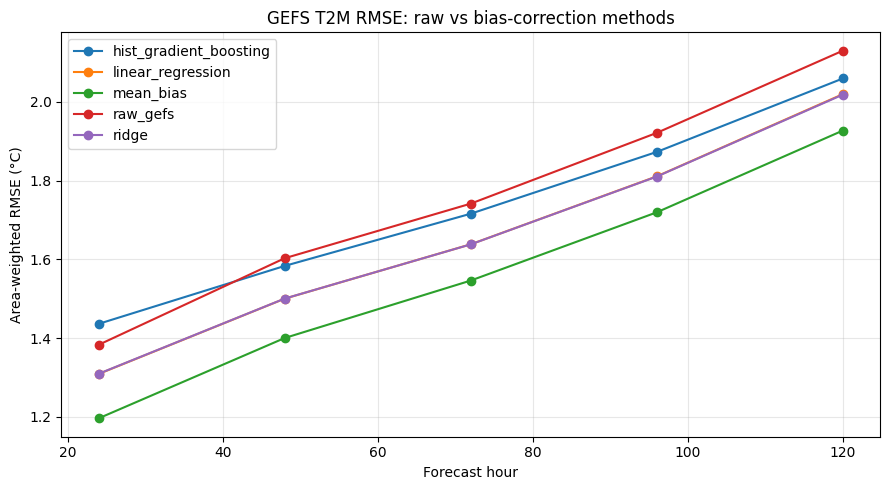

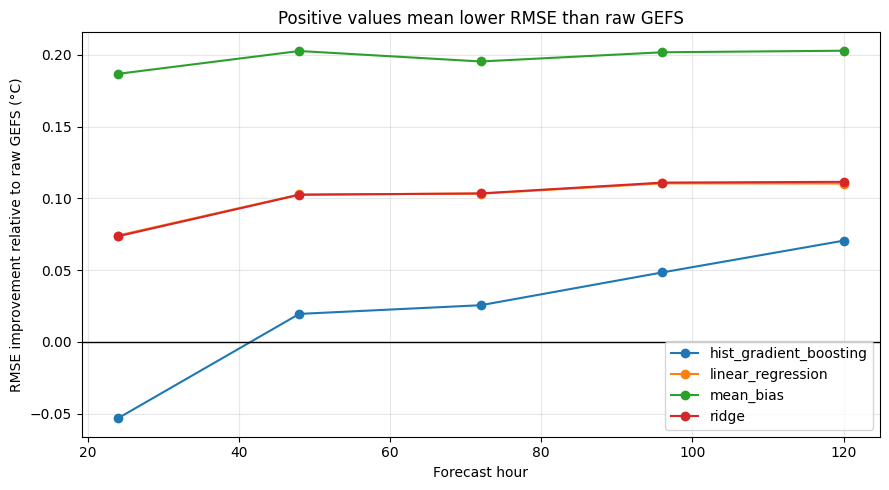

In [23]:
plot_rmse_by_fhr(results)
plot_rmse_improvement(results_with_improvement)

- RMSE increases with forecast hour for all methods, indicating larger errors at longer lead times.
- Mean-bias correction performs best, giving the largest and most consistent RMSE improvement over raw GEFS.
- Linear and ridge regression (almost same) provide moderate improvement, while HistGradientBoosting is weaker and even degrades f024 RMSE.

## 12. Spatial error example

This diagnostic map compares one test case. It helps show whether a correction method reduces spatially structured errors.

Best non-raw method by average RMSE improvement: mean_bias


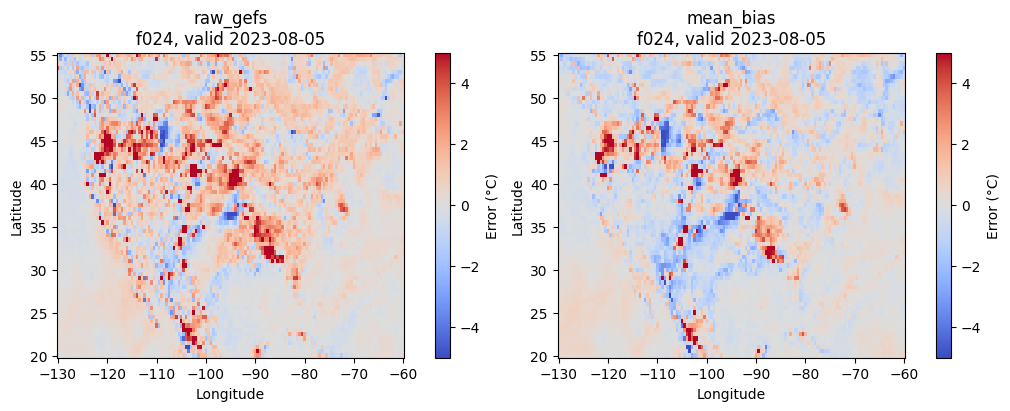

In [25]:
spatial_methods = {"mean_bias": mean_bias_corrected}

non_raw = results_with_improvement[results_with_improvement["method"] != "raw_gefs"]
best_method = (
    non_raw.groupby("method")["rmse_improvement_c"]
    .mean()
    .sort_values(ascending=False)
    .index[0]
)

if best_method in ml_corrected:
    spatial_methods[best_method] = ml_corrected[best_method]

print(f"Best non-raw method by average RMSE improvement: {best_method}")
plot_spatial_error_example(test_ds, spatial_methods, case_index=0, vmin=-5, vmax=5)

- Mean-bias correction reduces many of these warm-error regions, but some cold-error areas become stronger.
- The remaining errors are still spatially structured, meaning location-dependent errors remain important.

## 13. Summary and discussion

- Raw GEFS shows a consistent warm bias and increasing RMSE with forecast lead time.
- Mean-bias correction gives the strongest improvement, producing the lowest RMSE and MAE across all tested lead times.
- Linear regression and ridge regression improve RMSE compared with raw GEFS, but they do not outperform mean-bias correction.
- Histogram Gradient Boosting is less consistent and performs worse than the simpler linear models in this experiment.
- Spatial error maps show that mean-bias correction reduces many warm-error areas, but location-dependent errors remain.
- Overall, simple ML models provide useful correction signals, but the mean-bias baseline remains the most effective method for this current setup.

##Note on AI Assistance

This notebook was developed with AI. See the repository README for details.